In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Superstore_complete.csv', encoding= 'latin1')

print(df.shape)
print(df.columns.tolist())
print(df.head())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  U

# Region-Wise Sales

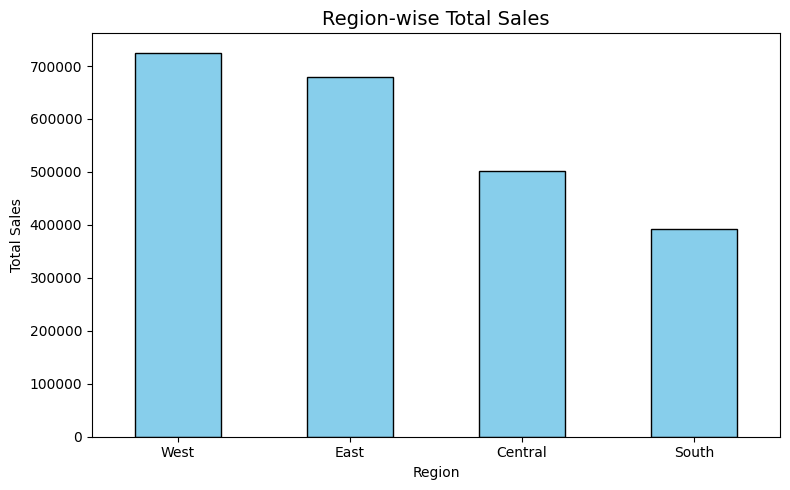

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [2]:
# Region-wise total sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Region-wise Total Sales', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('region_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print(region_sales)

# Category-wise Sales

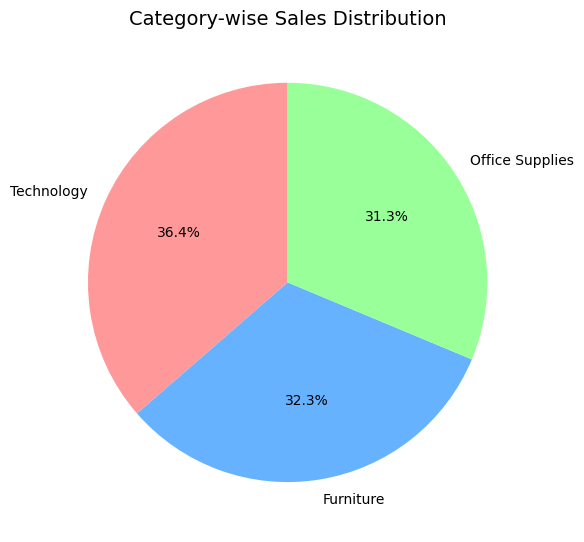

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [3]:
# Category-wise Total Sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%',
        colors=['#FF9999', '#66B2FF', '#99ff99'],
        startangle=90)
plt.title('Category-wise Sales Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('category_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print(category_sales)

# Top 10 Products

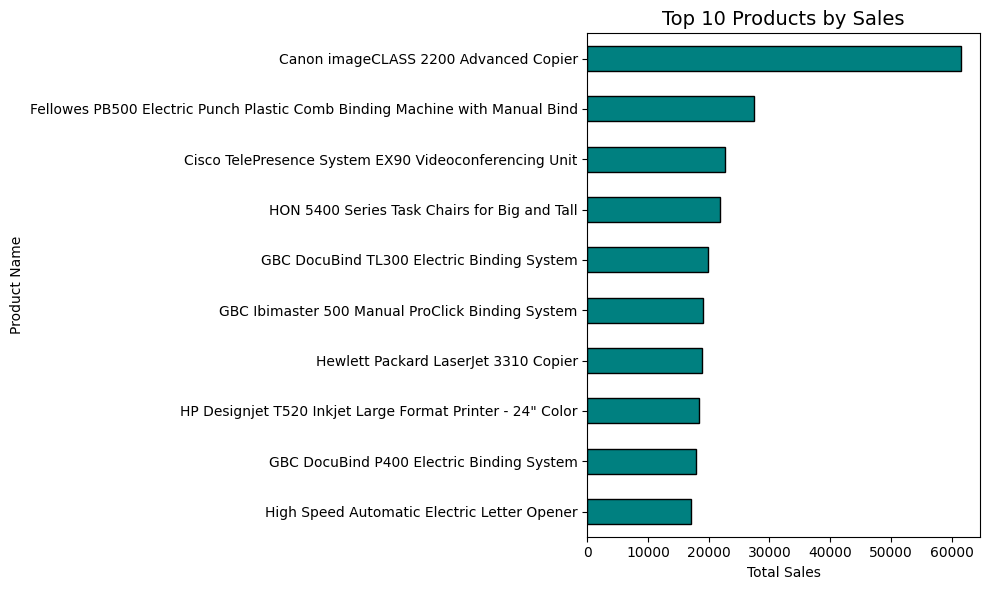

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [4]:
# Top 10 products by Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Products by Sales', fontsize=14)
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_products)
           

# Monthly Sales Trend

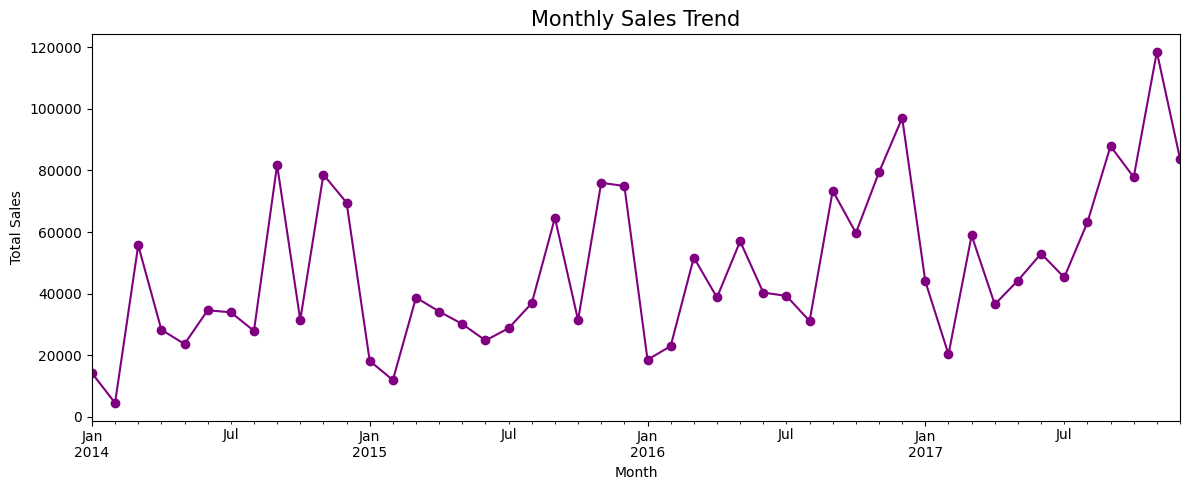

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Sales Trend', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()
                 


# Segment-wise Sales

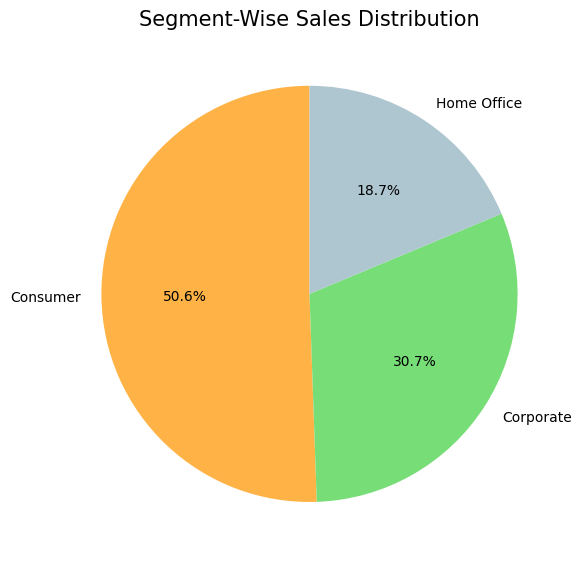

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


In [6]:
# Segment-wise Sales
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(segment_sales,
        labels=segment_sales.index,
        autopct='%1.1F%%',
        colors=['#FFB347','#77DD77','#AEC6CF'],
        startangle=90)
plt.title('Segment-Wise Sales Distribution', fontsize=15)
plt.tight_layout()
plt.savefig('segment_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print(segment_sales)                                                   

# Ship Mode Usage 

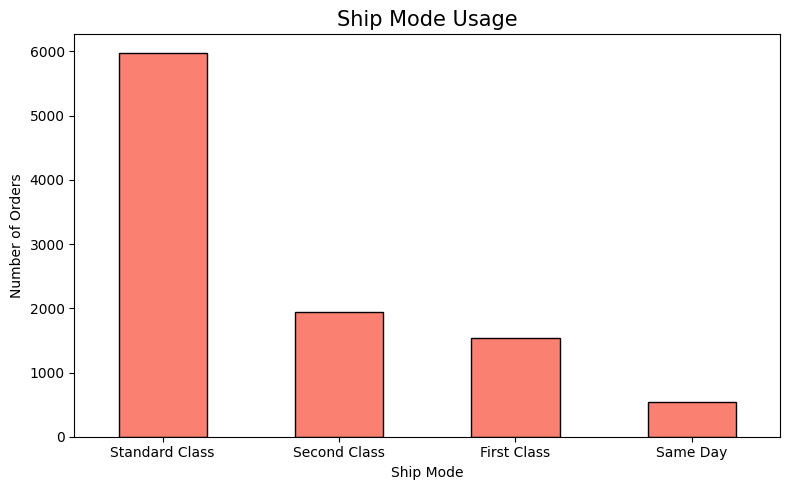

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


In [7]:
# Ship Mode Wise Count
ship_mode = df['Ship Mode'].value_counts()

plt.figure(figsize=(8,5))
ship_mode.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Ship Mode Usage', fontsize=15)
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('ship_mode.png', dpi=150, bbox_inches='tight')
plt.show()

print(ship_mode)

# Profit Analysis

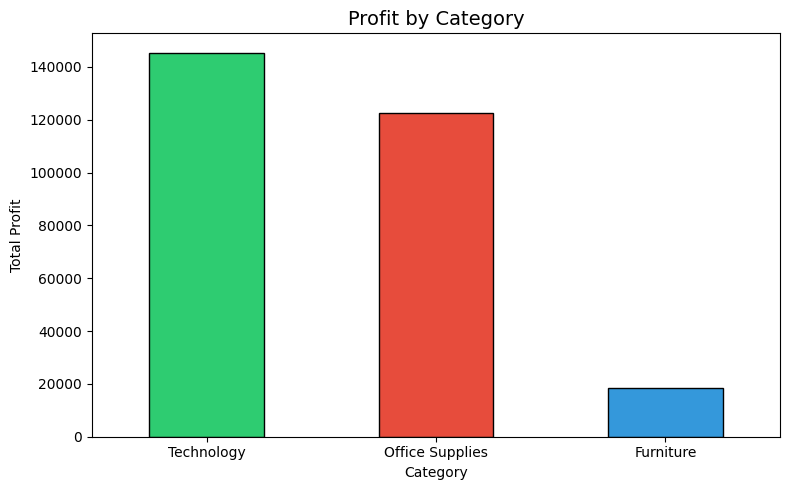

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [8]:
# Profit Analysis by category
profit_category  = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
profit_category.plot(kind='bar', color=['#2ecc71','#e74c3c','#3498db'], edgecolor='black')
plt.title('Profit by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('profit_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(profit_category)

# Discount vs Sales

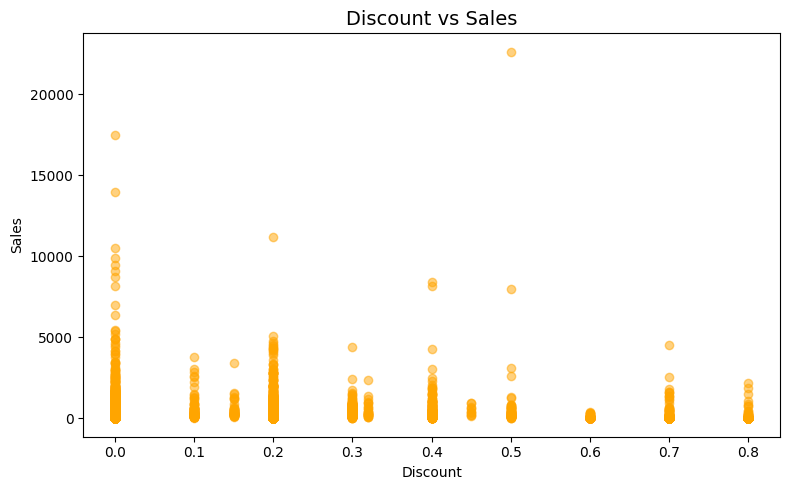

Total points plotted: 9994


In [9]:
# Discount Impact on Sales
df_clean = df.dropna(subset=['Discount', 'Sales'])

plt.figure(figsize=(8,5))
plt.scatter(df_clean['Discount'].values, df_clean['Sales'].values, alpha=0.5, color='orange')
plt.title('Discount vs Sales', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('discount_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total points plotted: {len(df_clean)}")


# Quantity by Category

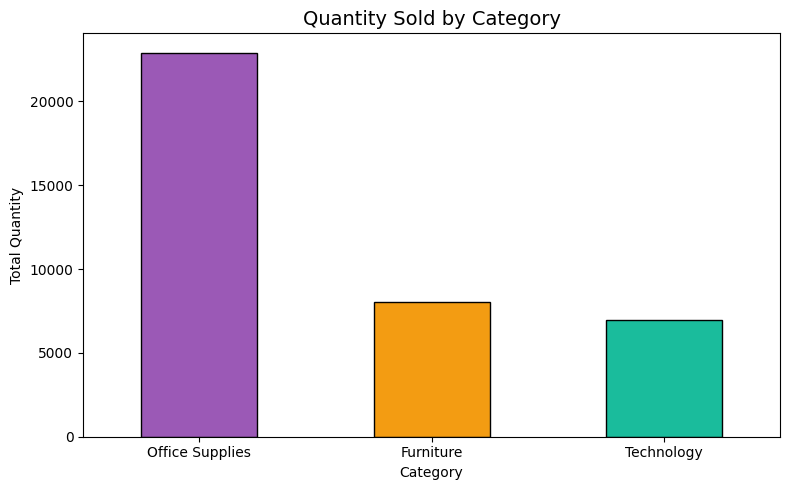

Category
Office Supplies    22906
Furniture           8028
Technology          6939
Name: Quantity, dtype: int64


In [10]:
# Quantity Sold by Category 
qty_category = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
qty_category.plot(kind='bar', color=['#9b59b6', '#f39c12', '#1abc9c'], edgecolor='black')
plt.title('Quantity Sold by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('quantity_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(qty_category)

# Complete Dataset Overview

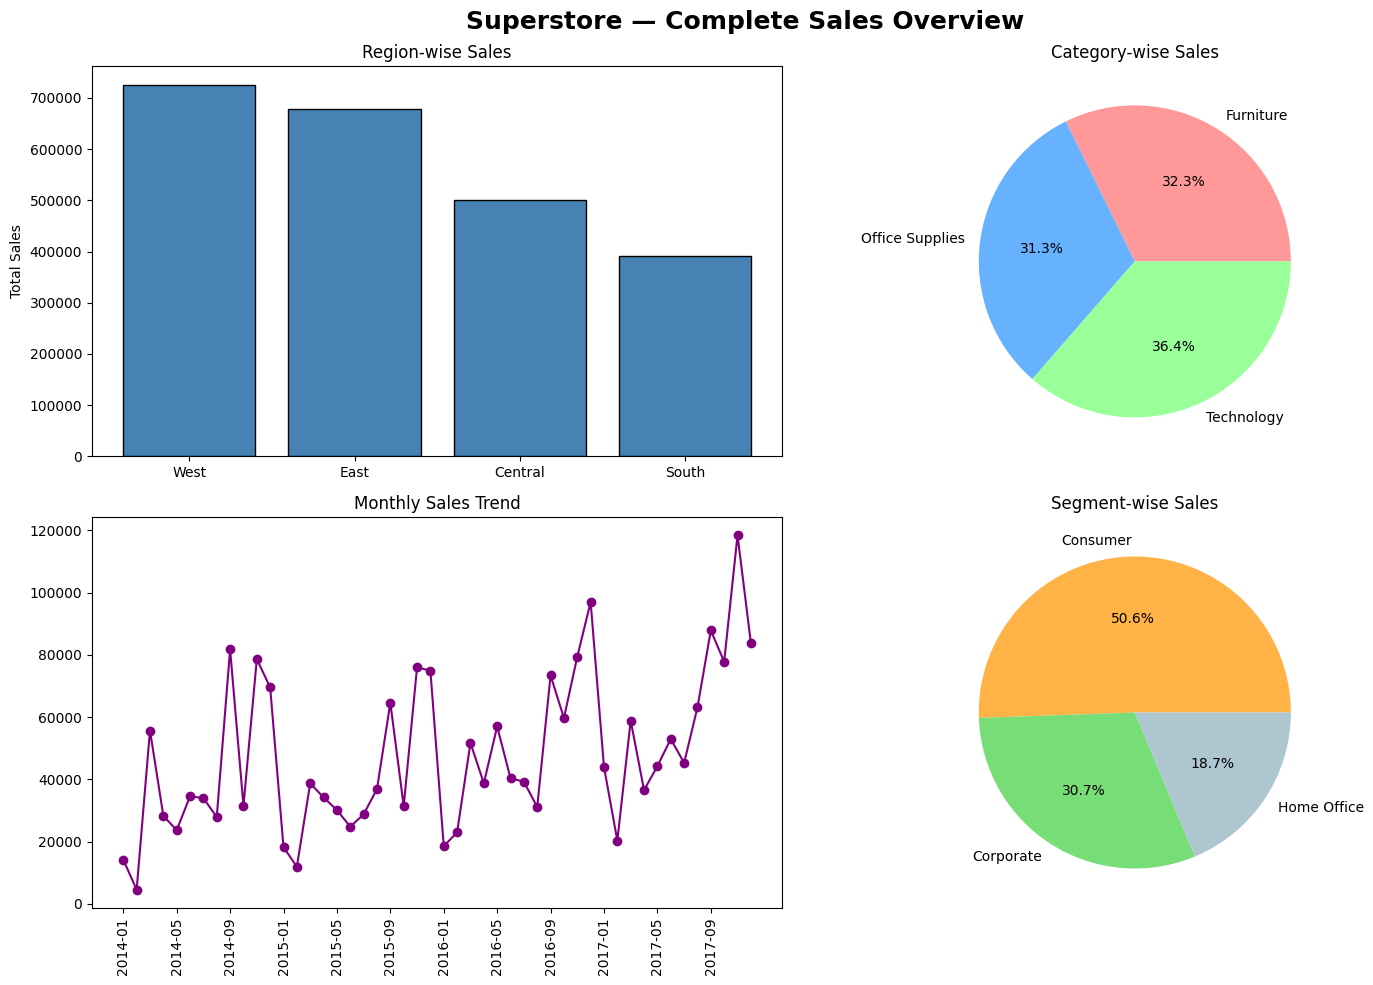

In [11]:
# Complete Dataset Overview - 4 charts in one figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Region-wise Sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(region_sales.index, region_sales.values, color='steelblue', edgecolor='black')
axes[0,0].set_title('Region-wise Sales')
axes[0,0].set_ylabel('Total Sales')

# 2. Category-wise Sales
category_sales = df.groupby('Category')['Sales'].sum()
axes[0,1].pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', colors=['#FF9999','#66B2FF','#99FF99'])
axes[0,1].set_title('Category-wise Sales')

# 3. Monthly Trend
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
axes[1,0].plot(monthly_sales.index.astype(str), monthly_sales.values, color='purple', marker='o')
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].set_xticks(axes[1,0].get_xticks()[::4])  # har 4th label dikhao

# 4. Segment-wise Sales
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[1,1].pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%', colors=['#FFB347','#77DD77','#AEC6CF'])
axes[1,1].set_title('Segment-wise Sales')

plt.suptitle('Superstore — Complete Sales Overview', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('overview_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()